In [1]:
from fastai.vision.all import *
# from sklearn.metrics import roc_curve, auc
from fastai.metrics import * 

# from pathlib import Path
from sklearn.model_selection import  train_test_split # GroupKFold, StratifiedGroupKFold, LeaveOneGroupOut, LeavePGroupsOut,
from sklearn.utils import resample
import sklearn.metrics as skm
path = Path('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v5')
import numpy as np
from numpy import random
import shutil
import glob

from torch.distributions.beta import Beta

# Test batch size = 1,300 on A100 GPU

In [2]:
# Create dataloader that uses balanced train/valid datasets generated above
re_class=r'class_(.+)_x\d+_y\d+.jpg'
# re_slide =r'(.+)_class_\S+_x\d+_y\d+.jpg$'

# size=224,
                                              # min_scale=0.75,
tissue =DataBlock(blocks=(ImageBlock, CategoryBlock),
                  get_items=get_image_files, 
                  splitter= GrandparentSplitter(train_name='train',valid_name='valid'),
                  get_y= parent_label , #using_attr(RegexLabeller(re_class), 'name')
                  #item_tfms=RandomResizedCrop(224,min_scale=0.75) <- can be performed in aug_trans
                  batch_tfms=aug_transforms(size=224,
                                            max_rotate=45,
                                            min_scale=0.75,
                                            flip_vert=True,
                                           )
                             ) #Normalize.from_stats(*imagenet_stats) < -- added by default by cnn_learner()
dls = tissue.dataloaders(path/"model",bs=1300) #A100 test bs = ~1300 w/ resnet34

/ihome/rbao/bri8/envs/fastai/lib/python3.8/site-packages/torch/_tensor.py:1023: UserWarning: torch.solve is deprecated in favor of torch.linalg.solveand will be removed in a future PyTorch release.
torch.linalg.solve has its arguments reversed and does not return the LU factorization.
To get the LU factorization see torch.lu, which can be used with torch.lu_solve or torch.lu_unpack.
X = torch.solve(B, A).solution
should be replaced with
X = torch.linalg.solve(A, B) (Triggered internally at  /opt/conda/conda-bld/pytorch_1631630839582/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:760.)
  ret = func(*args, **kwargs)


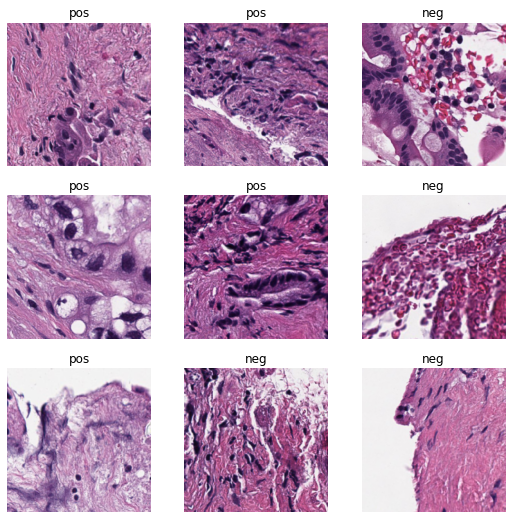

In [14]:
dls.show_batch(nrows=3, ncols=3)

In [102]:
class Mixup(Callback):
    run_valid = False
    
    def __init__(self, alpha=0.4): self.distrib = Beta(tensor(alpha), tensor(alpha))
    
    def before_batch(self):
        self.t = self.distrib.sample((self.y.size(0),)).squeeze().to(self.x.device)
        shuffle = torch.randperm(self.y.size(0)).to(self.x.device)
        x1,self.y1 = self.x[shuffle],self.y[shuffle]
        self.learn.xb = (x1 * (1-self.t[:,None,None,None]) + self.x * self.t[:,None,None,None],)
    
    def after_loss(self):
        with NoneReduce(self.loss_func) as lf:
            loss = lf(self.pred,self.y1) * (1-self.t) + lf(self.pred,self.y) * self.t
        self.learn.loss = loss.mean()

In [8]:
for key in model_meta.keys():
    print(key)

<function xresnet18 at 0x7f36cb8699d0>
<function xresnet34 at 0x7f36cb869a60>
<function xresnet50 at 0x7f36cb869af0>
<function xresnet101 at 0x7f36cb869b80>
<function xresnet152 at 0x7f36cb869c10>
<function resnet18 at 0x7f36ceaab940>
<function resnet34 at 0x7f36ceaab9d0>
<function resnet50 at 0x7f36ceac8700>
<function resnet101 at 0x7f36ceac8790>
<function resnet152 at 0x7f36ceac8820>
<function squeezenet1_0 at 0x7f36cead4670>
<function squeezenet1_1 at 0x7f36cead4700>
<function densenet121 at 0x7f36ce3f2280>
<function densenet169 at 0x7f36ce3f23a0>
<function densenet201 at 0x7f36ce3f2430>
<function densenet161 at 0x7f36ce3f2310>
<function vgg11_bn at 0x7f36ceac8e50>
<function vgg13_bn at 0x7f36ceac8f70>
<function vgg16_bn at 0x7f36cead40d0>
<function vgg19_bn at 0x7f36cead41f0>
<function alexnet at 0x7f36ceac83a0>


In [4]:
#Train a simple model:
# dls.bs=128*8 #Curious what the biggest batch size I might expect to be able to use
learn = cnn_learner(dls, resnet34,
                    metrics=[error_rate, accuracy],
                    ).to_fp16()

learn.fine_tune(10,freeze_epochs=1)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,1.240989,1.741376,0.484657,0.515343,00:39


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.976722,1.159759,0.473827,0.526173,00:39
1,0.946257,1.236606,0.455776,0.544224,00:40
2,0.895899,1.241112,0.435921,0.564079,00:39
3,0.850956,1.260533,0.431408,0.568592,00:40
4,0.809973,1.157220,0.419675,0.580325,00:40
5,0.765254,1.326138,0.425993,0.574007,00:40
6,0.730423,1.312116,0.416065,0.583935,00:40
7,0.700369,1.293217,0.411552,0.588448,00:41
8,0.675471,1.298055,0.413357,0.586643,00:43
9,0.654639,1.282288,0.404332,0.595668,00:43


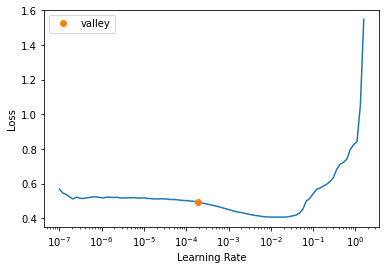

In [6]:
lr_min = learn.lr_find() #

In [7]:
learn.fit_one_cycle(5,1e-2)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.503460,22.126612,0.481047,0.518953,00:37
1,0.972365,nan,0.500000,0.500000,00:37
2,0.948201,nan,0.539711,0.460289,00:37
3,0.882675,1131.774536,0.500000,0.500000,00:38
4,0.848905,22.845434,0.497292,0.502708,00:37


In [5]:
keys = learn.recorder.hps.keys()
print(keys)
print(np.min(learn.recorder.hps['lr']))

dict_keys(['lr', 'mom'])
5.594544331293189e-06


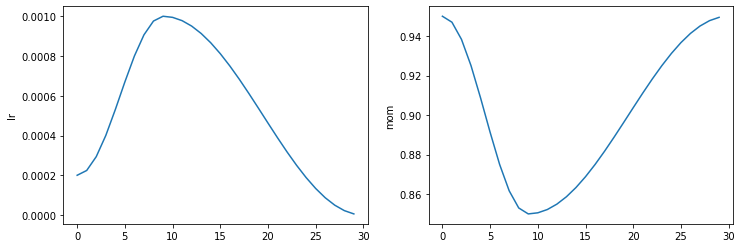

In [6]:
learn.recorder.plot_sched()

In [ ]:
lr_min=learn.lr_find()

In [8]:
test = DataBlock(blocks=(ImageBlock, CategoryBlock),
                  get_items=get_image_files, 
                  get_y= parent_label , #using_attr(RegexLabeller(re_class), 'name')
                  batch_tfms=aug_transforms(size=224,
                                              min_scale=0.75,
                                              flip_vert=True,
                                              max_rotate=25),
                 )
new_dls=test.dataloaders(path/"model"/"test")
x,y = new_dls.one_batch()
print(x.shape,y.shape)
preds,_ = learn.get_preds(dl=new_dls)
print(preds[1],y[1])
# print(len(preds[0]),preds[0].sum())


torch.Size([64, 3, 224, 224]) torch.Size([64])


TypeError: `dl` is something other than a single `DataLoader` object

In [158]:
dir(new_dls)

['_DataLoader__idxs',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_tfms',
 '_after_item',
 '_call',
 '_component_attr_filter',
 '_component_attr_filter',
 '_component_attr_filter',
 '_dbunch_type',
 '_dbunch_type',
 '_decode_batch',
 '_default',
 '_default',
 '_default',
 '_device',
 '_dir',
 '_dir',
 '_dir',
 '_dl_type',
 '_dl_type',
 '_do_call',
 '_docs',
 '_docs',
 '_get',
 '_is_showable',
 '_methods',
 '_n_inp',
 '_name',
 '_new',
 '_new',
 '_noop_methods',
 '_one_pass',
 '_pre_show_batch',
 '_repr_pretty_',
 '_retain_dl',
 '_set',
 '_types',
 'add',
 'add_na',
 'add_tfms',
 'after_batch',


366 188 260 294
sensitivity 0.5306859205776173
specificity 0.6606498194945848


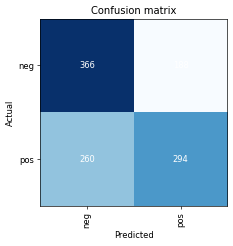

In [9]:
#Plot a confusion matrix
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(4,4), dpi=60)
upp, low = interp.confusion_matrix()
tn, fp = upp[0], upp[1]
fn, tp = low[0], low[1]
print(tn, fp, fn, tp)
sensitivity = tp/(tp + fn) #True pos / all positive
print('sensitivity',sensitivity)

specificity = tn/(fp + tn)
print('specificity',specificity) #True neg / all negative

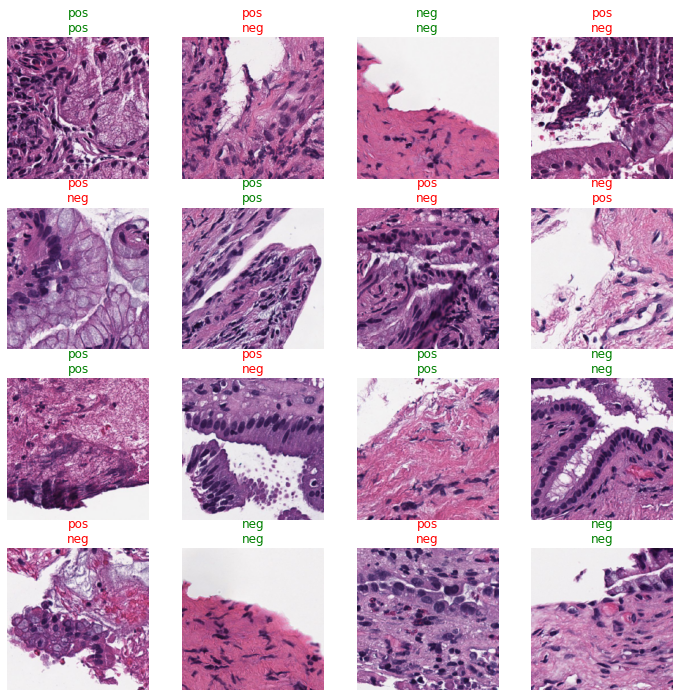

In [10]:
tta = learn.tta(use_max=True)
learn.show_results(max_n=16)

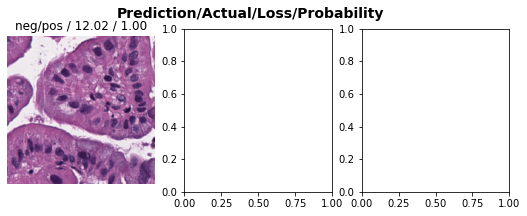

In [206]:
interp.plot_top_losses(3,nrows=1)

In [14]:
export_path=path.joinpath("model").joinpath("export")

train = path.joinpath('model').joinpath('train')
ftest=glob.glob(str(train.joinpath('**/*.jpg')),recursive=True)
if export_path.exists()==False:
    os.makedirs(str(export_path))
print('Saving to %s' % export_path)
learn.export(fname=export_path.joinpath('alexnet_170%dt_bs512_maxrot45_minscale_0p75_1frz_70ftune.pkl' % len(ftest)))

Saving to /ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v5/model/export


In [95]:
learn.recorder.before_train

<bound method Recorder.before_train of Recorder>

In [94]:
out=learn.get_preds(with_loss=True)
np.mean(np.array(out[2]))

0.04391727